# Fleet GPS analysis: Monty + turf.js

An agent asked for "where does my delivery fleet actually cover, and which depot should serve what?" and writes two programs, because each language has a job it is good at. **Python, in Monty** simulates a fleet of delivery vehicles driving depot -> stops -> depot (deterministic hash-based random walks, GPS jitter, dropouts and a few wild spikes), then cleans every track: drops points that imply an impossible speed, resamples at a fixed interval, and computes per-vehicle statistics. **JavaScript, in pydeno** runs turf.js to buffer each track by 150 m and union the buffers into a coverage area, wrap the stops in a convex and a concave hull, cut the city into Voronoi service zones around the depots, find the nearest depot for each stop, compute the closest approach between every pair of tracks, and draw one SVG map. Neither half is trusted: neither can touch files, network or environment, only the host functions handed to it.

```
pip install pydeno pydantic-monty
```

Imports and the shared constants (vendored Turf bundle path, buffer radius, Earth's radius so both halves agree on it).

In [1]:
import pathlib
import sys
import time
from typing import Any

from pydeno import WEB_POLYFILLS, IsolatedRuntime, RuntimeConfig

try:
    from pydantic_monty import Monty
except ImportError:
    sys.exit("This example pairs pydeno with Monty: pip install pydantic-monty")

# Adapted for a notebook: no `__file__`, so resolve relative to the repo root
# (this notebook is executed with that as its working directory).
def _repo_root() -> pathlib.Path:
    """Walk up from the current directory to find the pydeno checkout: this notebook is run
    with the repo root as its cwd when executed from the command line, but opening it directly
    in Jupyter normally starts in its own directory (examples/notebooks/) instead."""
    for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (candidate / "vendor" / "libs").is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("run this notebook from inside a pydeno checkout")


LIBS = _repo_root() / "vendor" / "libs"
TURF_BUNDLE = "turf-7.4.0.bundle.js"

SIZES = [4, 8, 12]  # number of vehicles
BUFFER_METERS = 150  # the coverage radius around every track
EARTH_RADIUS_M = (
    6371008.8  # the radius Turf uses, so both halves measure the same Earth
)

The Monty half, as a string of plain Python (no imports beyond `math`, no files): simulate each vehicle's GPS track, then clean and resample it.

In [2]:
MODEL_PYTHON = """
import math

R = 6371008.8
LON0, LON1 = 8.46, 8.60
LAT0, LAT1 = 47.33, 47.43
DEPOTS = [
    ["Oerlikon", 8.5446, 47.4113],
    ["Altstetten", 8.4890, 47.3910],
    ["Enge", 8.5310, 47.3640],
    ["Stettbach", 8.5900, 47.3930],
]
STOPS_PER_VEHICLE = 5
STEP = 10.0
RESAMPLE = 30.0
MAX_SPEED = 35.0


def hash3(a, b, c, seed):
    h = (a * 374761393 + b * 668265263 + c * 2246822519 + seed * 1274126177) % 4294967296
    h = ((h ^ (h >> 13)) * 1274126177) % 4294967296
    h = (h ^ (h >> 16)) % 4294967296
    return (h % 100000) / 100000.0


def haversine(lon1, lat1, lon2, lat2):
    p1 = math.radians(lat1)
    p2 = math.radians(lat2)
    dp = p2 - p1
    dl = math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


def clamp(x, lo, hi):
    return max(lo, min(hi, x))


def simulate(v):
    depot = DEPOTS[v % len(DEPOTS)]
    waypoints = [[depot[1], depot[2]]]
    stops = []
    for k in range(STOPS_PER_VEHICLE):
        if hash3(v, k, 1, SEED) < 0.7:
            cx, cy, spread = depot[1], depot[2], 0.07
        else:
            cx, cy, spread = (LON0 + LON1) / 2, (LAT0 + LAT1) / 2, 0.16
        lon = clamp(cx + (hash3(v, k, 2, SEED) - 0.5) * spread, LON0, LON1)
        lat = clamp(cy + (hash3(v, k, 3, SEED) - 0.5) * spread * 0.6, LAT0, LAT1)
        stops.append([round(lon, 5), round(lat, 5)])
        waypoints.append([lon, lat])
    waypoints.append([depot[1], depot[2]])

    raw = []
    t = 0.0
    leg = 0
    lon, lat = waypoints[0]
    tick = 0
    while leg < len(waypoints) - 1 and tick < 4000:
        tlon, tlat = waypoints[leg + 1]
        remaining = haversine(lon, lat, tlon, tlat)
        speed = 8.0 + 4.0 * hash3(v, tick, 4, SEED)
        reach = speed * STEP
        dwell = 0
        if reach >= remaining:
            lon, lat = tlon, tlat
            leg += 1
            dwell = 3
        else:
            f = reach / remaining
            lon += (tlon - lon) * f
            lat += (tlat - lat) * f
        for _ in range(1 + dwell):
            t += STEP
            tick += 1
            u = hash3(v, tick, 5, SEED)
            if u < 0.04:
                continue  # a dropout: the logger lost the fix
            jlat = (hash3(v, tick, 6, SEED) - 0.5) * 12.0 / 111320.0
            jlon = (hash3(v, tick, 7, SEED) - 0.5) * 12.0 / (111320.0 * math.cos(math.radians(lat)))
            plon = lon + jlon
            plat = lat + jlat
            if u > 0.985:
                plon += 0.03  # a wild spike, ~2 km away
                plat += 0.01
            raw.append([t, plon, plat])
    return depot, stops, raw


def clean(raw):
    kept = [raw[0]]
    dropped = 0
    for p in raw[1:]:
        last = kept[-1]
        d = haversine(last[1], last[2], p[1], p[2])
        if d / (p[0] - last[0]) > MAX_SPEED:
            dropped += 1
        else:
            kept.append(p)
    out = []
    T = kept[0][0]
    i = 0
    while T <= kept[-1][0]:
        while kept[i + 1][0] < T:
            i += 1
        a = kept[i]
        b = kept[i + 1]
        f = (T - a[0]) / (b[0] - a[0])
        out.append([round(a[1] + (b[1] - a[1]) * f, 6), round(a[2] + (b[2] - a[2]) * f, 6)])
        T += RESAMPLE
    return out, dropped


vehicles = []
for v in range(V):
    depot, stops, raw = simulate(v)
    track, dropped = clean(raw)
    dist = 0.0
    top = 0.0
    for k in range(1, len(track)):
        leg_m = haversine(track[k - 1][0], track[k - 1][1], track[k][0], track[k][1])
        dist += leg_m
        top = max(top, leg_m / RESAMPLE)
    vehicles.append({
        "id": "V" + str(v + 1),
        "depot": v % len(DEPOTS),
        "stops": stops,
        "track": track,
        "raw_points": len(raw),
        "dropped": dropped,
        "distance_m": round(dist, 3),
        "max_speed_ms": round(top, 3),
        "mean_speed_ms": round(dist / (RESAMPLE * (len(track) - 1)), 3),
    })

{
    "depots": [[d[1], d[2], d[0]] for d in DEPOTS],
    "extent": [LON0, LAT0, LON1, LAT1],
    "buffer_m": BUFFER_M,
    "vehicles": vehicles,
}
"""

The pydeno half, as a string of JavaScript: turf.js measures, buffers, unions, builds hulls and Voronoi zones, finds nearest depots and closest approaches, and draws the SVG map. `getFleet()` is the one host function it can call, and it only ever sees what Python handed it.

In [3]:
MODEL_JAVASCRIPT = """
globalThis.buildMap = (size) => {
  const fleet = getFleet();
  const km = { units: 'kilometers' };
  const depotFc = turf.featureCollection(
    fleet.depots.map(([lon, lat, name], i) => turf.point([lon, lat], { name, i })));
  const lines = fleet.vehicles.map((v) => turf.lineString(v.track, { id: v.id }));

  // 1. track lengths
  const lengthKm = lines.map((l) => turf.length(l, km));

  // 2. coverage: a buffer round every track, unioned
  const buffers = lines.map((l) => turf.buffer(l, fleet.buffer_m / 1000, { ...km, steps: 4 }));
  const bufferAreas = buffers.map((b) => turf.area(b));
  const coverage = buffers.length > 1 ? turf.union(turf.featureCollection(buffers)) : buffers[0];

  // 3. hulls round every stop
  const stopFc = turf.featureCollection(
    fleet.vehicles.flatMap((v) => v.stops.map((s) => turf.point(s, { v: v.id }))));
  const convex = turf.convex(stopFc);
  const concave = turf.concave(stopFc, { maxEdge: 6, units: 'kilometers' }) || convex;

  // 4. Voronoi service zones around the depots, over the padded extent
  const [x0, y0, x1, y1] = fleet.extent;
  const zones = turf.voronoi(depotFc, { bbox: [x0, y0, x1, y1] });

  // 5. nearest depot for every stop
  const nearest = stopFc.features.map((s) => {
    const n = turf.nearestPoint(s, depotFc);
    return { vehicle: s.properties.v, stop: s.geometry.coordinates, depot: n.properties.i,
             meters: n.properties.distanceToPoint * 1000 };
  });

  // 6. closest approach between every pair of tracks
  // The minimum between two polylines is reached at a vertex of one of them, so it is enough to
  // measure every vertex against the other line. Turf's point-to-line call is slow under a
  // jitless V8, so a cheap planar lower bound skips the vertices that provably cannot improve the
  // answer: a point is at least (distance to the other line's nearest vertex - half its longest
  // segment) from that line. Exact, and it avoids most of the calls.
  const M_DEG = 111195 * 0.995; // metres per degree, shaded down so the bound stays a lower bound
  const kxm = Math.cos((fleet.extent[1] * Math.PI) / 180) * M_DEG; // smallest cosine in the extent
  const xy = fleet.vehicles.map((v) => v.track.map(([lon, lat]) => [lon * kxm, lat * M_DEG]));
  const halfLongest = xy.map((t) => {
    let L = 0;
    for (let i = 1; i < t.length; i++) L = Math.max(L, Math.hypot(t[i][0] - t[i - 1][0], t[i][1] - t[i - 1][1]));
    return L / 2 * 1.01;
  });
  const closest = (a, b, best) => {
    for (let i = 0; i < xy[a].length; i++) {
      let near = Infinity;
      for (const q of xy[b]) near = Math.min(near, Math.hypot(xy[a][i][0] - q[0], xy[a][i][1] - q[1]));
      if (near - halfLongest[b] >= best) continue;
      best = Math.min(best, turf.pointToLineDistance(turf.point(fleet.vehicles[a].track[i]), lines[b], km) * 1000);
    }
    return best;
  };
  const approach = [];
  for (let a = 0; a < lines.length; a++) {
    for (let b = a + 1; b < lines.length; b++) {
      const best = closest(b, a, closest(a, b, Infinity));
      approach.push({ a: fleet.vehicles[a].id, b: fleet.vehicles[b].id, meters: best });
    }
  }

  // 7. one SVG map, equirectangular, fitted to the bounding box of everything drawn
  const bb = turf.bbox(turf.featureCollection([...lines, coverage, ...zones.features, ...depotFc.features]));
  const mid = (bb[1] + bb[3]) / 2;
  const kx = Math.cos((mid * Math.PI) / 180);
  const W = 900, pad = 24, scale = (W - 2 * pad) / ((bb[2] - bb[0]) * kx);
  const H = Math.round((bb[3] - bb[1]) * scale + 2 * pad);
  const X = (lon) => (pad + (lon - bb[0]) * kx * scale).toFixed(1);
  const Y = (lat) => (H - pad - (lat - bb[1]) * scale).toFixed(1);
  const ring = (r) => r.map(([lon, lat]) => X(lon) + ',' + Y(lat)).join(' ');
  const poly = (f, attrs) => {
    const g = f.geometry;
    const rings = g.type === 'Polygon' ? [g.coordinates] : g.coordinates;
    return rings.map((p) => '<path ' + attrs + ' fill-rule="evenodd" d="' +
      p.map((r) => 'M' + ring(r).replace(/ /g, 'L') + 'Z').join('') + '"/>').join('');
  };
  const palette = ['#2a6f97', '#bc4749', '#6a994e', '#9d4edd', '#e07a1f', '#0b7285'];
  const zoneFill = ['#dbe9f4', '#f6dcdc', '#e1eed7', '#ebdcf7'];
  const parts = [];
  parts.push('<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 ' + W + ' ' + H +
    '" width="' + W + '" height="' + H + '" font-family="sans-serif" font-size="11">');
  parts.push('<rect width="' + W + '" height="' + H + '" fill="#fbfaf7"/>');
  zones.features.forEach((z, i) => parts.push(
    poly(z, 'fill="' + zoneFill[i % 4] + '" stroke="#8a8a8a" stroke-width="1" stroke-dasharray="6 4"')));
  parts.push(poly(coverage, 'fill="#264653" fill-opacity="0.18" stroke="#264653" stroke-width="0.8"'));
  parts.push(poly(concave, 'fill="none" stroke="#c1121f" stroke-width="1.4" stroke-dasharray="2 3"'));
  parts.push(poly(convex, 'fill="none" stroke="#c1121f" stroke-width="1"'));
  fleet.vehicles.forEach((v, i) => parts.push('<polyline fill="none" stroke="' + palette[i % 6] +
    '" stroke-width="1.6" stroke-opacity="0.9" points="' + ring(v.track) + '"><title>' + v.id +
    '</title></polyline>'));
  nearest.forEach((n) => parts.push('<circle cx="' + X(n.stop[0]) + '" cy="' + Y(n.stop[1]) +
    '" r="3" fill="#fff" stroke="#222" stroke-width="1"/>'));
  fleet.depots.forEach(([lon, lat, name]) => parts.push('<rect x="' + (X(lon) - 5) + '" y="' +
    (Y(lat) - 5) + '" width="10" height="10" fill="#111"/><text x="' + (+X(lon) + 8) + '" y="' +
    (+Y(lat) + 4) + '" fill="#111" font-weight="bold">' + name + '</text>'));
  parts.push('</svg>');

  const km2 = (f) => turf.area(f) / 1e6;
  return {
    svg: parts.join(''),
    stats: {
      vehicles: fleet.vehicles.map((v, i) => ({ id: v.id, lengthKm: lengthKm[i] })),
      bufferAreasM2: bufferAreas,
      largestBufferM2: Math.max(...bufferAreas),
      sumBufferM2: bufferAreas.reduce((s, x) => s + x, 0),
      coverageAreaM2: turf.area(coverage),
      coverageKm2: km2(coverage),
      convexKm2: km2(convex),
      concaveKm2: km2(concave),
      zones: zones.features.length,
      nearest,
      closestApproach: approach,
      stops: stopFc.features.length,
    },
  };
};
"""

One Monty pool and one warm pydeno runtime, reused across maps.

In [4]:
class GeoPipeline:
    """One Monty pool and one warm pydeno runtime, reused across maps."""

    def __init__(self, *, jitless: bool = True) -> None:
        self.monty = Monty().__enter__()
        self.rt = IsolatedRuntime(
            RuntimeConfig(bootstrap=WEB_POLYFILLS, timeout=120.0),
            sandbox="require",
            request_timeout=300,
            jitless=jitless,
        )
        self._fleet: dict[str, Any] = {}
        self.rt.bind_function("getFleet", lambda: self._fleet)
        self.load_seconds = 0.0

    def load_turf(self) -> None:
        start = time.perf_counter()
        self.rt.eval((LIBS / TURF_BUNDLE).read_text() + "\n;0")
        self.rt.eval(MODEL_JAVASCRIPT + "\n;0")
        self.load_seconds = time.perf_counter() - start

    def prepare(self, vehicles: int, seed: int = 7) -> dict[str, Any]:
        """Python half, in Monty."""
        with self.monty.checkout() as session:
            return session.feed_run(
                MODEL_PYTHON,
                inputs={"V": vehicles, "SEED": seed, "BUFFER_M": BUFFER_METERS},
            )

    def render(self, size: int) -> tuple[str, dict[str, Any], dict[str, float]]:
        """`size` vehicles -> (svg text, statistics, timings)."""
        t0 = time.perf_counter()
        self._fleet = self.prepare(size)
        t1 = time.perf_counter()
        out = self.rt.eval(f"buildMap({size})")
        t2 = time.perf_counter()
        return (
            out["svg"],
            out["stats"],
            {"monty_prepare": t1 - t0, "js_build": t2 - t1, "total": t2 - t0},
        )

    def close(self) -> None:
        self.rt.close()
        self.monty.__exit__(None, None, None)


PIPELINE = GeoPipeline

Run it: Monty prepares a fleet, turf.js builds the map, and the result is an SVG plus the numbers behind it.

In [5]:
size = 8
pipe = GeoPipeline()
print(f"sandbox: {pipe.rt.sandbox}")
pipe.load_turf()
print(f"Turf.js loaded into the sandbox in {pipe.load_seconds * 1000:.0f} ms")
svg, stats, t = pipe.render(size)
total_km = sum(v["lengthKm"] for v in stats["vehicles"])
closest = min(stats["closestApproach"], key=lambda c: c["meters"], default=None)
print(
    f"{size} vehicles, {stats['stops']} stops: {total_km:.1f} km driven, "
    f"coverage {stats['coverageKm2']:.2f} km2 (150 m buffers), "
    f"convex hull {stats['convexKm2']:.1f} km2, concave {stats['concaveKm2']:.1f} km2, "
    f"{stats['zones']} Voronoi zones"
)
if closest:
    print(
        f"  closest approach: {closest['a']} and {closest['b']} "
        f"came within {closest['meters']:.0f} m"
    )
print(f"  monty cleaned the tracks  {t['monty_prepare'] * 1000:8.0f} ms")
print(f"  turf.js analysis + SVG    {t['js_build'] * 1000:8.0f} ms")
print(f"wrote fleet.svg ({len(svg) / 1024:.0f} KiB) in {t['total'] * 1000:.0f} ms total")
pathlib.Path("fleet.svg").write_text(svg)
pipe.close()

sandbox: seatbelt
Turf.js loaded into the sandbox in 22 ms


8 vehicles, 40 stops: 212.8 km driven, coverage 45.92 km2 (150 m buffers), convex hull 95.2 km2, concave 92.6 km2, 4 Voronoi zones
  closest approach: V3 and V6 came within 0 m
  monty cleaned the tracks        17 ms
  turf.js analysis + SVG        2042 ms
wrote fleet.svg (33 KiB) in 2059 ms total


The map: vehicle tracks, their 150 m buffer union, convex/concave hulls round the stops, and Voronoi service zones around the depots.

4 Voronoi zones, 40 stops, 8 vehicle tracks


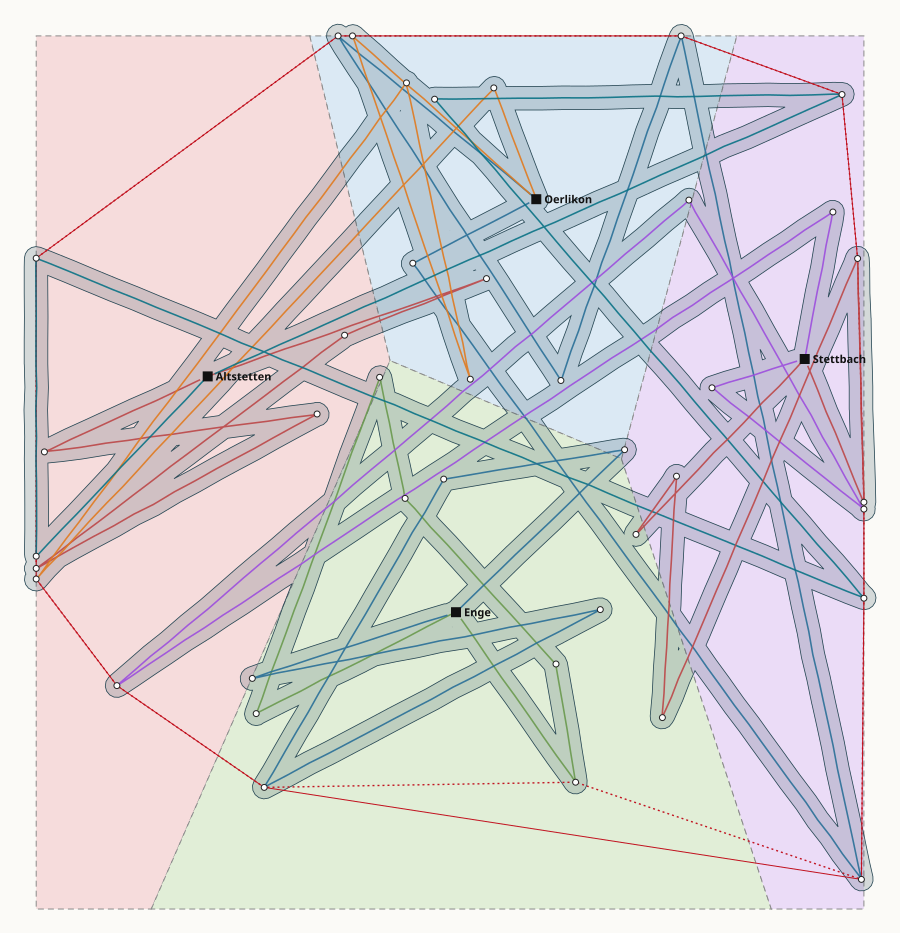

In [6]:
from IPython.display import SVG, display

print(f"{stats['zones']} Voronoi zones, {stats['stops']} stops, {len(stats['vehicles'])} vehicle tracks")
display(SVG(svg))